In [19]:
!pip install -q torch torchvision tqdm kagglehub nltk matplotlib pandas

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
import os
import csv
import math
from PIL import Image
from collections import Counter
from tqdm import tqdm
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_ROOT = '/content/drive/MyDrive/FYP_Models/Attention_Captioning'
os.makedirs(DRIVE_ROOT, exist_ok=True)

MODEL_PATH   = os.path.join(DRIVE_ROOT, 'resnet50_attention_model.pth')
VOCAB_PATH   = os.path.join(DRIVE_ROOT, 'vocab.pt')
FEATURE_PATH = os.path.join(DRIVE_ROOT, 'resnet50_features.pt')

print('Drive directory ready:', DRIVE_ROOT)

Drive directory ready: /content/drive/MyDrive/FYP_Models/Attention_Captioning


In [5]:
import kagglehub
path = kagglehub.dataset_download('adityajn105/flickr8k')
IMAGE_DIR    = os.path.join(path, 'Images')
CAPTION_FILE = os.path.join(path, 'captions.txt')
print(len(os.listdir(IMAGE_DIR)), 'images found')
print('Caption file exists:', os.path.exists(CAPTION_FILE))

Using Colab cache for faster access to the 'flickr8k' dataset.
8091 images found
Caption file exists: True


In [6]:
# ── FIX 1: Custom tokenizer ──────────────────────────────────────────────────
# nltk.word_tokenize splits '<start>' into ['<', 'start', '>'] which breaks
# everything. This simple whitespace tokenizer preserves the special tokens.

def tokenize(caption: str):
    """Lowercase, strip noise, keep <start>/<end> as single tokens."""
    caption = caption.lower().strip()
    # keep letters, apostrophes, and angle-bracket tokens
    caption = re.sub(r"[^a-z0-9<>' ]", ' ', caption)
    # ensure special tokens are surrounded by spaces
    caption = caption.replace('<start>', ' <start> ').replace('<end>', ' <end> ')
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption.split()

# quick sanity check
test = '<start> A dog runs across the field . <end>'
print(tokenize(test))

['<start>', 'a', 'dog', 'runs', 'across', 'the', 'field', '<end>']


In [7]:
# ── Load captions ─────────────────────────────────────────────────────────────
captions = {}
with open(CAPTION_FILE, 'r') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if len(row) >= 2:
            img_name     = row[0]
            caption_text = '<start> ' + row[1].strip() + ' <end>'
            captions.setdefault(img_name, []).append(caption_text)

print('Total images with captions:', len(captions))

Total images with captions: 8091


In [8]:
# ── FIX 2: Build vocab with <unk> ────────────────────────────────────────────
word_counter = Counter()
SKIP_TOKENS = {'<pad>', '<start>', '<end>', '<unk>'}
for caps_list in captions.values():
    for cap in caps_list:
        # exclude special tokens from the frequency counter
        word_counter.update(t for t in tokenize(cap) if t not in SKIP_TOKENS)

# specials first — order matters: pad=0, start=1, end=2, unk=3
SPECIALS = ['<pad>', '<start>', '<end>', '<unk>']
word2idx = {w: i for i, w in enumerate(SPECIALS)}
idx2word = {i: w for i, w in enumerate(SPECIALS)}

idx = len(SPECIALS)
MIN_FREQ = 5
for w, c in word_counter.items():
    if c >= MIN_FREQ and w not in word2idx:
        word2idx[w] = idx
        idx2word[idx] = w
        idx += 1

vocab_size = len(word2idx)
PAD_IDX   = word2idx['<pad>']
START_IDX = word2idx['<start>']
END_IDX   = word2idx['<end>']
UNK_IDX   = word2idx['<unk>']

print(f'Vocabulary size: {vocab_size}')
print(f'  <pad>={PAD_IDX}, <start>={START_IDX}, <end>={END_IDX}, <unk>={UNK_IDX}')

torch.save((word2idx, idx2word), VOCAB_PATH)
print('Vocabulary saved to Drive.')

Vocabulary size: 2982
  <pad>=0, <start>=1, <end>=2, <unk>=3
Vocabulary saved to Drive.


In [9]:
# ── Caption → index sequence (OOV → <unk>, NOT <pad>) ────────────────────────
def caption_to_seq(caption: str):
    return [word2idx.get(w, UNK_IDX) for w in tokenize(caption)]

# sanity check
seq = caption_to_seq('<start> a dog runs <end>')
print('Example seq:', seq)
print('Decoded    :', [idx2word[i] for i in seq])

Example seq: [1, 4, 28, 123, 2]
Decoded    : ['<start>', 'a', 'dog', 'runs', '<end>']


## Dataset, DataLoader & Feature Extraction

In [10]:
# ── Train / val split (90 / 10) ───────────────────────────────────────────────
all_images = list(captions.keys())
random.seed(42)
random.shuffle(all_images)
split = int(0.9 * len(all_images))
train_images = all_images[:split]
val_images   = all_images[split:]
print(f'Train: {len(train_images)} | Val: {len(val_images)}')

Train: 7281 | Val: 810


In [11]:
# ── Feature extraction with ResNet50 ─────────────────────────────────────────
# Returns spatial feature map (B, 49, 2048) — used by attention

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Build encoder: ResNet50 up to layer4, output shape (B, 2048, 7, 7)
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
encoder = nn.Sequential(*list(resnet.children())[:-2])
encoder = encoder.to(device).eval()
for p in encoder.parameters():
    p.requires_grad = False

print('Encoder ready. Spatial output: 7×7 = 49 locations, 2048-dim each.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


Encoder ready. Spatial output: 7×7 = 49 locations, 2048-dim each.


In [12]:
# ── Extract & cache features (skip if already saved) ─────────────────────────
if os.path.exists(FEATURE_PATH):
    print('Loading cached features from Drive...')
    all_features = torch.load(FEATURE_PATH, map_location='cpu', weights_only=False)
    print(f'Loaded features for {len(all_features)} images.')
else:
    print('Extracting features (this takes a few minutes)...')
    all_features = {}
    with torch.no_grad():
        for img_name in tqdm(all_images):
            img_path = os.path.join(IMAGE_DIR, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img_t = transform(img).unsqueeze(0).to(device)  # (1,3,224,224)
                feat = encoder(img_t)                           # (1,2048,7,7)
                feat = feat.squeeze(0).permute(1, 2, 0)         # (7,7,2048)
                feat = feat.reshape(49, 2048).cpu()             # (49,2048)
                all_features[img_name] = feat
            except Exception as e:
                print(f'  Skipping {img_name}: {e}')

    torch.save(all_features, FEATURE_PATH)
    print(f'Features for {len(all_features)} images saved to Drive.')

Loading cached features from Drive...
Loaded features for 8091 images.


In [13]:
from torch.utils.data import Dataset, DataLoader

class Flickr8kDataset(Dataset):
    """Each item is (feature, caption_seq) pair. One item per caption."""
    def __init__(self, image_names, max_len=50):
        self.data = []
        self.max_len = max_len
        for img_name in image_names:
            if img_name not in all_features:
                continue
            for cap in captions[img_name]:
                seq = caption_to_seq(cap)
                if len(seq) <= max_len:
                    self.data.append((img_name, seq))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, seq = self.data[idx]
        feat = all_features[img_name]  # (49, 2048)
        return feat, torch.tensor(seq, dtype=torch.long)


def collate_fn(batch):
    feats, seqs = zip(*batch)
    feats = torch.stack(feats)  # (B, 49, 2048)
    max_len = max(s.size(0) for s in seqs)
    padded = torch.full((len(seqs), max_len), PAD_IDX, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :s.size(0)] = s
    return feats, padded


BATCH_SIZE = 64
train_dataset = Flickr8kDataset(train_images)
val_dataset   = Flickr8kDataset(val_images)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}')

Train samples: 36405 | Val samples: 4050


## Model: Attention + LSTM Decoder

In [14]:
# ── Additive Attention ─────────────────────────────────────────
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attn_dim):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim, attn_dim)
        self.W_dec = nn.Linear(decoder_dim, attn_dim)
        self.V     = nn.Linear(attn_dim, 1)

    def forward(self, encoder_out, h):
        # encoder_out: (B, 49, encoder_dim)  h: (B, decoder_dim)
        e = self.W_enc(encoder_out)              # (B, 49, attn_dim)
        d = self.W_dec(h).unsqueeze(1)           # (B, 1,  attn_dim)
        score = self.V(torch.tanh(e + d))        # (B, 49, 1)
        alpha = torch.softmax(score, dim=1)      # (B, 49, 1)
        context = (alpha * encoder_out).sum(1)   # (B, encoder_dim)
        return context, alpha.squeeze(-1)        # (B, encoder_dim), (B, 49)


# ── LSTM Decoder ──────────────────────────────────────────────────────────────
class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, encoder_dim=2048,
                 decoder_dim=512, attn_dim=256, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = Attention(encoder_dim, decoder_dim, attn_dim)
        self.lstm      = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h    = nn.Linear(encoder_dim, decoder_dim)
        self.init_c    = nn.Linear(encoder_dim, decoder_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(decoder_dim, vocab_size)

    def _init_hidden(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)       # (B, encoder_dim)
        h = torch.tanh(self.init_h(mean_enc))    # (B, decoder_dim)
        c = torch.tanh(self.init_c(mean_enc))
        return h, c

    def forward(self, encoder_out, captions, teacher_forcing_ratio=1.0):
        """
        FIX 3 — Correct teacher-forcing alignment.
        captions : (B, T) — full sequence including <start> and <end>
        returns  : logits (B, T-1, vocab_size)  targets = captions[:, 1:]
        """
        B, T = captions.size()
        h, c = self._init_hidden(encoder_out)

        outputs = []
        input_token = captions[:, 0]             # always <start>

        for t in range(T - 1):                   # predict tokens 1 … T-1
            emb              = self.embedding(input_token)          # (B, embed_dim)
            context, alpha   = self.attention(encoder_out, h)       # (B, enc_dim)
            lstm_in          = torch.cat([emb, context], dim=1)     # (B, E+enc)
            h, c             = self.lstm(lstm_in, (h, c))
            logits           = self.fc(self.dropout(h))             # (B, V)
            outputs.append(logits)

            # teacher forcing: use ground-truth or model prediction
            use_gt = random.random() < teacher_forcing_ratio
            input_token = captions[:, t + 1] if use_gt else logits.argmax(1)

        return torch.stack(outputs, dim=1)       # (B, T-1, V)


# instantiate
model = DecoderWithAttention(
    vocab_size   = vocab_size,
    embed_dim    = 256,
    encoder_dim  = 2048,
    decoder_dim  = 512,
    attn_dim     = 256,
    dropout      = 0.5,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Decoder parameters: {total_params:,}')
print('Model freshly initialised — ready to train from scratch.')

Decoder parameters: 10,818,727
Model freshly initialised — ready to train from scratch.


## Training

In [15]:
# ── Loss: cross-entropy with label smoothing (0.05) ───────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.05)

# ── Optimizer & scheduler ─────────────────────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

NUM_EPOCHS = 35
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


In [16]:
def train_epoch(loader, tf_ratio):
    model.train()
    total_loss = 0
    for feats, caps in loader:
        feats = feats.to(device)   # (B, 49, 2048)
        caps  = caps.to(device)    # (B, T)

        # FIX 3: outputs = predictions for tokens 1..T-1, targets = caps[:, 1:]
        outputs = model(feats, caps, teacher_forcing_ratio=tf_ratio)  # (B, T-1, V)
        targets = caps[:, 1:]                                          # (B, T-1)

        loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def val_epoch(loader):
    model.eval()
    total_loss = 0
    for feats, caps in loader:
        feats = feats.to(device)
        caps  = caps.to(device)
        outputs = model(feats, caps, teacher_forcing_ratio=1.0)
        targets = caps[:, 1:]
        loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)


print('Train / val functions ready.')

Train / val functions ready.


In [17]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, NUM_EPOCHS + 1):
    tf_ratio = max(0.75, 1.0 - 0.005 * (epoch - 1))

    train_loss = train_epoch(train_loader, tf_ratio)
    val_loss   = val_epoch(val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch':      epoch,
            'model':      model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'word2idx':   word2idx,
            'idx2word':   idx2word,
        }, MODEL_PATH)
        flag = '  ✓ saved'
    else:
        flag = ''

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train {train_loss:.4f} | Val {val_loss:.4f} | '
          f'TF {tf_ratio:.2f}{flag}')

Epoch   1/35 | Train 4.0253 | Val 3.4825 | TF 1.00  ✓ saved
Epoch   2/35 | Train 3.3323 | Val 3.2802 | TF 0.99  ✓ saved
Epoch   3/35 | Train 3.0937 | Val 3.2035 | TF 0.99  ✓ saved
Epoch   4/35 | Train 2.9262 | Val 3.1797 | TF 0.98  ✓ saved
Epoch   5/35 | Train 2.7869 | Val 3.1735 | TF 0.98  ✓ saved
Epoch   6/35 | Train 2.6755 | Val 3.1783 | TF 0.97
Epoch   7/35 | Train 2.5749 | Val 3.1954 | TF 0.97
Epoch   8/35 | Train 2.4882 | Val 3.2074 | TF 0.96
Epoch   9/35 | Train 2.4122 | Val 3.2246 | TF 0.96
Epoch  10/35 | Train 2.3423 | Val 3.2480 | TF 0.95
Epoch  11/35 | Train 2.2779 | Val 3.2693 | TF 0.95
Epoch  12/35 | Train 2.2259 | Val 3.2961 | TF 0.94
Epoch  13/35 | Train 2.1602 | Val 3.3198 | TF 0.94
Epoch  14/35 | Train 2.1180 | Val 3.3268 | TF 0.94
Epoch  15/35 | Train 2.0642 | Val 3.3601 | TF 0.93
Epoch  16/35 | Train 2.0268 | Val 3.3885 | TF 0.93
Epoch  17/35 | Train 2.0023 | Val 3.3978 | TF 0.92
Epoch  18/35 | Train 1.9444 | Val 3.4197 | TF 0.92
Epoch  19/35 | Train 1.9305 | Val 3.4

In [21]:
# Create training summary table
results_df = pd.DataFrame({
    'Epoch': range(1, NUM_EPOCHS + 1),
    'Train Loss': history['train_loss'],
    'Val Loss': history['val_loss'],
})

# Add some derived metrics
results_df['Train-Val Gap'] = results_df['Val Loss'] - results_df['Train Loss']
results_df['Best So Far'] = results_df['Val Loss'].cummin()

print("\nTraining Summary (first 10 and last 5 epochs):")
print(results_df.head(10))
print("...")
print(results_df.tail(5))

# Save to CSV
results_df.to_csv(os.path.join(DRIVE_ROOT, 'training_results.csv'), index=False)
print(f"\nResults saved to: {os.path.join(DRIVE_ROOT, 'training_results.csv')}")

# Identify best epoch
best_epoch = results_df['Val Loss'].idxmin() + 1
print(f"\nBest epoch: {best_epoch} with val loss: {results_df['Val Loss'].min():.4f}")


Training Summary (first 10 and last 5 epochs):
   Epoch  Train Loss  Val Loss  Train-Val Gap  Best So Far
0      1    4.025258  3.482541      -0.542718     3.482541
1      2    3.332288  3.280233      -0.052054     3.280233
2      3    3.093717  3.203520       0.109803     3.203520
3      4    2.926198  3.179669       0.253471     3.179669
4      5    2.786908  3.173540       0.386632     3.173540
5      6    2.675542  3.178327       0.502785     3.173540
6      7    2.574947  3.195404       0.620457     3.173540
7      8    2.488178  3.207411       0.719234     3.173540
8      9    2.412238  3.224648       0.812411     3.173540
9     10    2.342305  3.248018       0.905713     3.173540
...
    Epoch  Train Loss  Val Loss  Train-Val Gap  Best So Far
30     31    1.688509  3.570082       1.881573      3.17354
31     32    1.704337  3.571616       1.867278      3.17354
32     33    1.689498  3.573116       1.883618      3.17354
33     34    1.710419  3.573014       1.862595      3.17354

Plot saved to: /content/drive/MyDrive/FYP_Models/Attention_Captioning/loss_curves.png


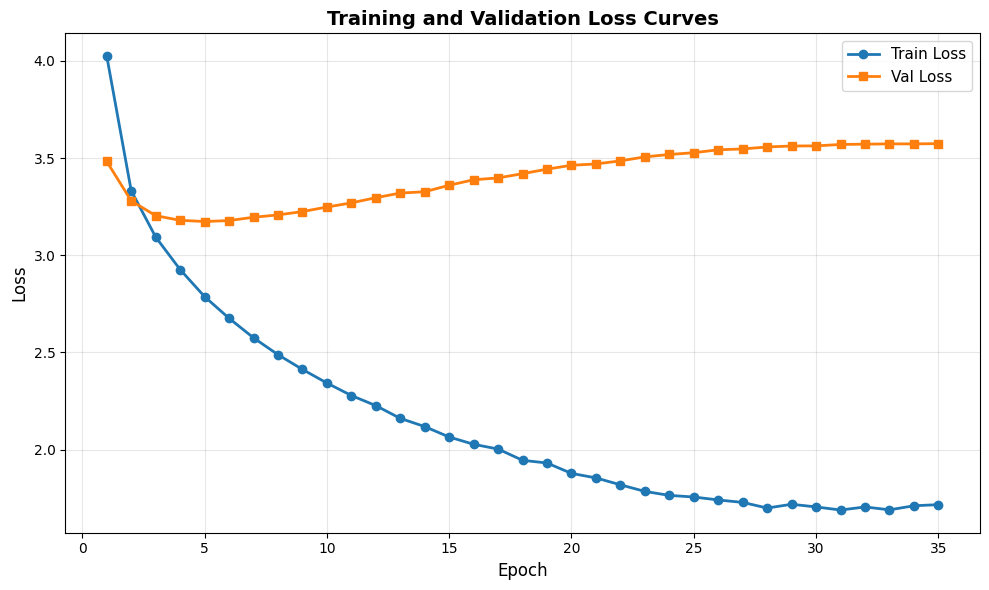

In [22]:
# Plot training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'],
         label='Train Loss', marker='o', linewidth=2)
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'],
         label='Val Loss', marker='s', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot to Google Drive
plot_path = os.path.join(DRIVE_ROOT, 'loss_curves.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f'Plot saved to: {plot_path}')

plt.show()

## BLEU-4 Evaluation on Validation Set

In [23]:
# ── FIX 4: Beam search decoding ───────────────────────────────────────────────
@torch.no_grad()
def beam_search(feature, beam_size=5, max_len=50):
    """
    feature : (49, 2048) CPU tensor for a single image.
    Returns : list of token strings (the best caption, without <start>/<end>).
    """
    model.eval()
    enc = feature.unsqueeze(0).to(device)         # (1, 49, 2048)
    h, c = model._init_hidden(enc)                # (1, decoder_dim)

    # each beam: [sequence of token ids, log-prob, h, c]
    beams = [([START_IDX], 0.0, h.clone(), c.clone())]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for seq, score, h, c in beams:
            tok = torch.tensor([seq[-1]], device=device)
            emb = model.embedding(tok)                     # (1, embed_dim)
            ctx, _ = model.attention(enc, h)
            lstm_in = torch.cat([emb, ctx], dim=1)
            h_new, c_new = model.lstm(lstm_in, (h, c))
            logits = model.fc(model.dropout(h_new))        # (1, V)

            # FIX 4: mask <pad> so it can never be chosen
            logits[0, PAD_IDX] = -1e9

            log_probs = torch.log_softmax(logits, dim=-1)  # (1, V)
            topk_lp, topk_idx = log_probs[0].topk(beam_size)

            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                new_seq   = seq + [idx]
                new_score = score + lp
                if idx == END_IDX:
                    completed.append((new_seq, new_score))
                else:
                    new_beams.append((new_seq, new_score, h_new, c_new))

        # keep top-k open beams
        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_size]
        if not beams:
            break

    if not completed:
        completed = [(b[0], b[1]) for b in beams]

    # pick best by length-normalised score
    best_seq, _ = max(completed, key=lambda x: x[1] / len(x[0]))

    # strip <start> and <end>
    tokens = [idx2word[i] for i in best_seq
              if i not in (START_IDX, END_IDX, PAD_IDX)]
    return tokens


print('Beam search ready.')

Beam search ready.


In [24]:
# ── Load best checkpoint before evaluating ────────────────────────────────────
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f'Loaded best model from epoch {ckpt["epoch"]}.')

# ── BLEU-4 on validation images ───────────────────────────────────────────────
smoothie = SmoothingFunction().method4
refs_all, hyps_all = [], []

for img_name in tqdm(val_images, desc='BLEU eval'):
    if img_name not in all_features:
        continue
    feat = all_features[img_name]
    hyp  = beam_search(feat, beam_size=5)
    refs = [tokenize(c) for c in captions[img_name]]  # list of ref token lists
    hyps_all.append(hyp)
    refs_all.append(refs)

bleu4 = corpus_bleu(refs_all, hyps_all, smoothing_function=smoothie)
print(f'\nValidation BLEU-4: {bleu4:.4f}')

Loaded best model from epoch 5.


BLEU eval: 100%|██████████| 810/810 [02:39<00:00,  5.09it/s]



Validation BLEU-4: 0.2263


## Generate a Caption for Own Image

In [ ]:
# ── Always load the best checkpoint before generating ─────────────────────────
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Loaded best model from epoch {ckpt["epoch"]}.')


@torch.no_grad()
def generate_caption(image_path: str, beam_size: int = 5):
    """Load an image and return a generated caption string."""
    img  = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)

    encoder.eval()
    feat = encoder(img_t)                  # (1, 2048, 7, 7)
    feat = feat.squeeze(0).permute(1, 2, 0).reshape(49, 2048).cpu()

    tokens = beam_search(feat, beam_size=beam_size)
    return ' '.join(tokens)


# ── Upload an image and test ──────────────────────────────────────────────────
from google.colab import files

uploaded = files.upload()
for image_path in uploaded.keys():
    caption = generate_caption(image_path)
    print(f'\n🖼️  {image_path}')
    print(f'Caption: {caption}')

Loaded best model from epoch 5.


Saving 1211015912_9f3ee3a995.jpg to 1211015912_9f3ee3a995.jpg

🖼️  1211015912_9f3ee3a995.jpg
Caption: a girl in a white dress is standing next to a girl in a pink dress
